In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [6]:
df_sal = pd.read_csv('../data/position_salary.csv')
df_sal.head(10)

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [4]:
df_sal.describe(include='all')

,Position,Level,Salary
count,10,10.00000,10.000000
unique,10,NaN,NaN
top,Business Analyst,NaN,NaN
freq,1,NaN,NaN
mean,NaN,5.50000,249500.000000
std,NaN,3.02765,299373.883668
min,NaN,1.00000,45000.000000
25%,NaN,3.25000,65000.000000
50%,NaN,5.50000,130000.000000
75%,NaN,7.75000,275000.000000


In [5]:
df_sal['Level'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

/var/folders/qj/csh4ys_506qc4hr_myvhtfym0000gn/T/ipykernel_64829/1150752203.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_sal['Salary'])


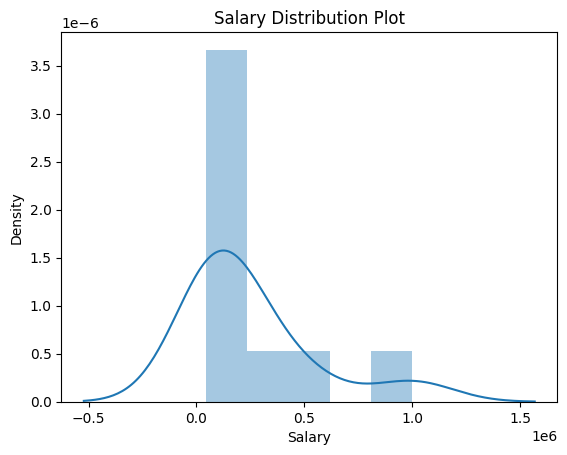

In [7]:
plt.title('Salary Distribution Plot')
sns.distplot(df_sal['Salary'])
plt.show()

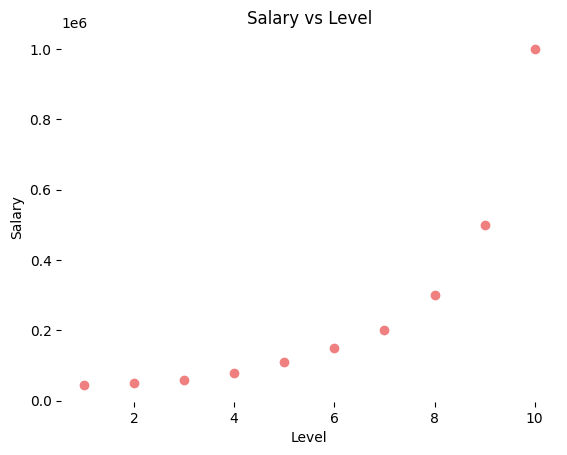

In [10]:
plt.scatter(df_sal['Level'], df_sal['Salary'], color = 'lightcoral')
plt.title('Salary vs Level')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.box(False)
plt.show()

In [12]:
log_salary = np.log(df_sal['Salary'])
df_sal['log_salary'] = log_salary

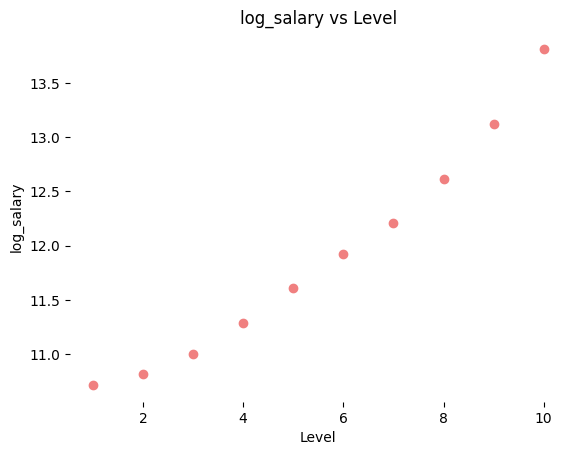

In [13]:
plt.scatter(df_sal['Level'], df_sal['log_salary'], color = 'lightcoral')
plt.title('log_salary vs Level')
plt.xlabel('Level')
plt.ylabel('log_salary')
plt.box(False)
plt.show()

<h2>We can use log in this example. but we cannpt use if we have negative data</h2>

In [15]:
df_sal=df_sal.drop('log_salary', axis=1)

In [16]:
X = df_sal.iloc[:, 1:-1].values  # independent
y = df_sal.iloc[:, -1].values  # dependent

In [19]:
y

array([  45000,   50000,   60000,   80000,  110000,  150000,  200000,
        300000,  500000, 1000000])

In [25]:
# Train linear regression model on whole dataset
lr = LinearRegression()
lr.fit(X, y)

# Train polynomial regression model on the whole dataset
pr = PolynomialFeatures(degree = 2)
X_poly = pr.fit_transform(X)
lr_2 = LinearRegression()
lr_2.fit(X_poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
y_pred_lr = lr.predict(X)
y_pred_poly = lr_2.predict(X_poly)

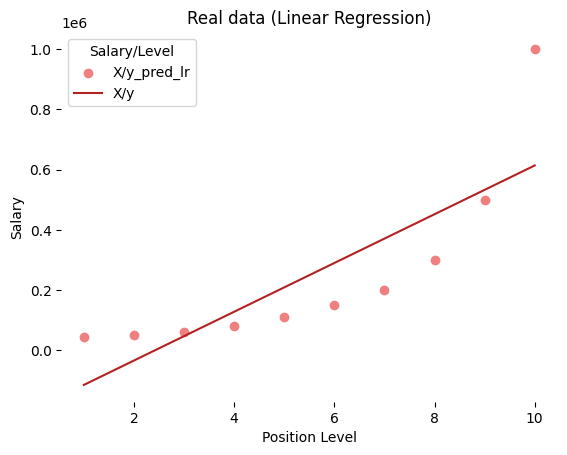

In [27]:
plt.scatter(X, y, color = 'lightcoral')
plt.plot(X, lr.predict(X), color = 'firebrick')
plt.title('Real data (Linear Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend(['X/y_pred_lr', 'X/y'], title = 'Salary/Level', loc='best', facecolor='white')
plt.box(False)
plt.show()

/var/folders/qj/csh4ys_506qc4hr_myvhtfym0000gn/T/ipykernel_64829/4120868496.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


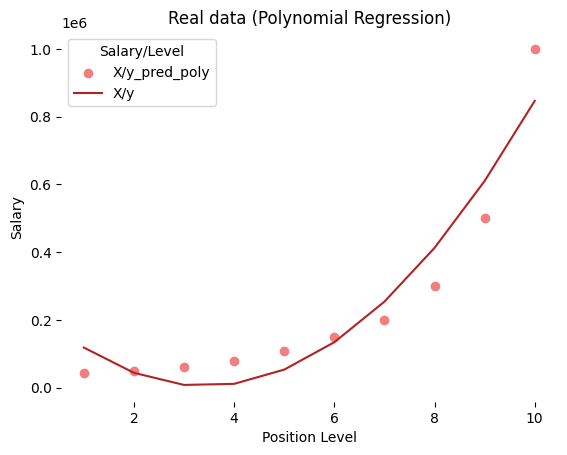

In [28]:
X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color = 'lightcoral')
plt.plot(X, lr_2.predict(X_poly), color = 'firebrick')
plt.title('Real data (Polynomial Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend(['X/y_pred_poly', 'X/y'], title = 'Salary/Level', loc='best', facecolor='white')
plt.box(False)
plt.show()

In [24]:
print(f'Linear Regression result : {lr.predict([[7.5]])}')

print(f'Polynomial Regression result : {lr_2.predict(pr.fit_transform([[7.5]]))}')

Linear Regression result : [411257.57575758]
Polynomial Regression result : [225126.29297781]


Degree 1: MSE = 26695878787.878784


/var/folders/qj/csh4ys_506qc4hr_myvhtfym0000gn/T/ipykernel_64829/3061457122.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


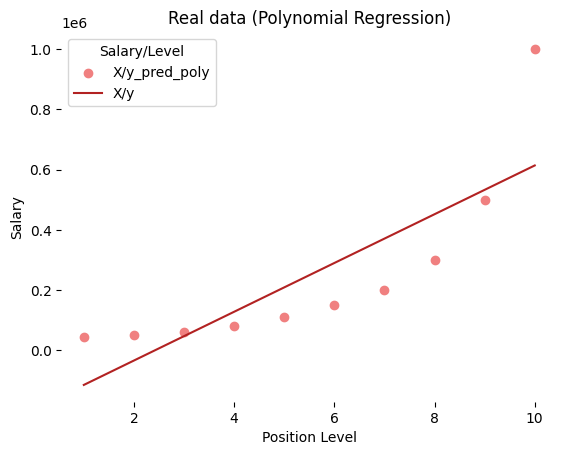

Degree 2: MSE = 6758833333.333336


/var/folders/qj/csh4ys_506qc4hr_myvhtfym0000gn/T/ipykernel_64829/3061457122.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


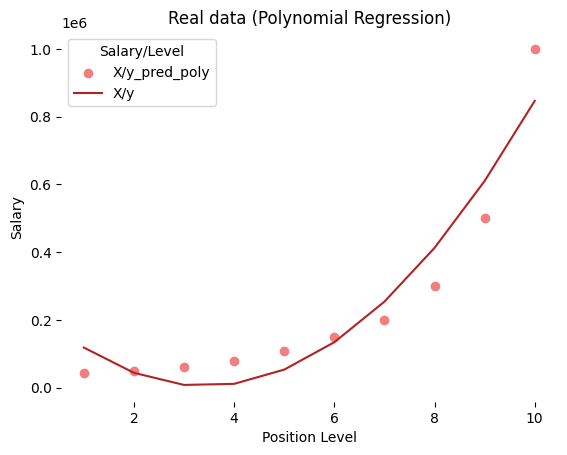

Degree 3: MSE = 1515662004.662002


/var/folders/qj/csh4ys_506qc4hr_myvhtfym0000gn/T/ipykernel_64829/3061457122.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


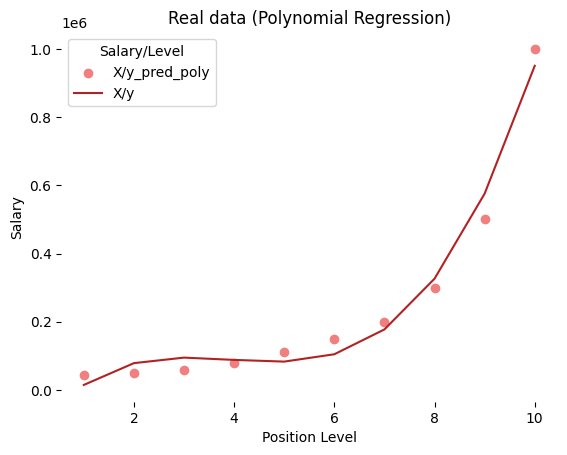

Degree 4: MSE = 210343822.84381407


/var/folders/qj/csh4ys_506qc4hr_myvhtfym0000gn/T/ipykernel_64829/3061457122.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


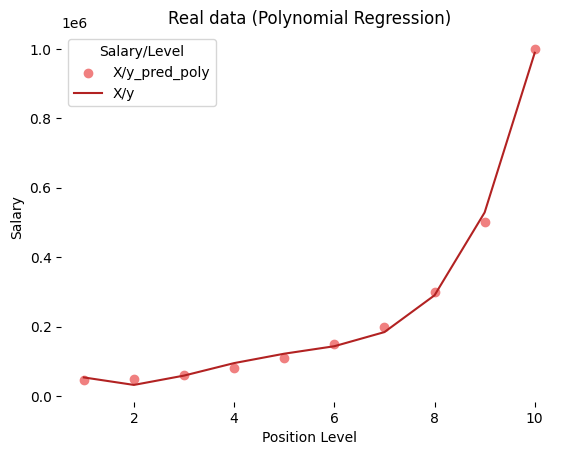

Degree 5: MSE = 16382284.382286673


/var/folders/qj/csh4ys_506qc4hr_myvhtfym0000gn/T/ipykernel_64829/3061457122.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


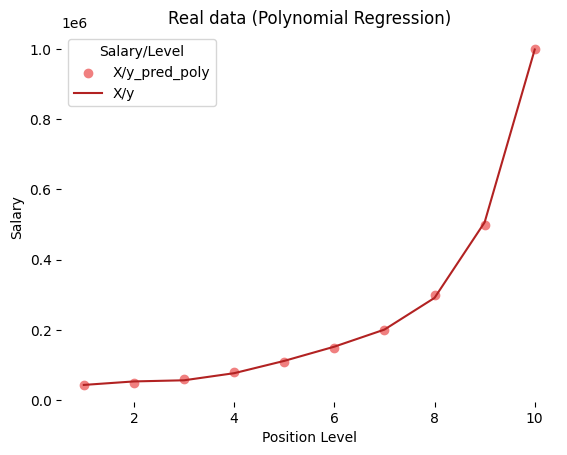

In [32]:
for d in [1, 2, 3, 4, 5]:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    
    y_pred = model.predict(X_poly)
    print(f"Degree {d}: MSE = {mean_squared_error(y, y_pred)}")

    X_grid = np.arange(min(X), max(X), 0.1)
    X_grid = X_grid.reshape((len(X_grid), 1))
    plt.scatter(X, y, color = 'lightcoral')
    plt.plot(X, y_pred, color = 'firebrick')
    plt.title('Real data (Polynomial Regression)')
    plt.xlabel('Position Level')
    plt.ylabel('Salary')
    plt.legend(['X/y_pred_poly', 'X/y'], title = 'Salary/Level', loc='best', facecolor='white')
    plt.box(False)
    plt.show()